/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_17/960380586.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


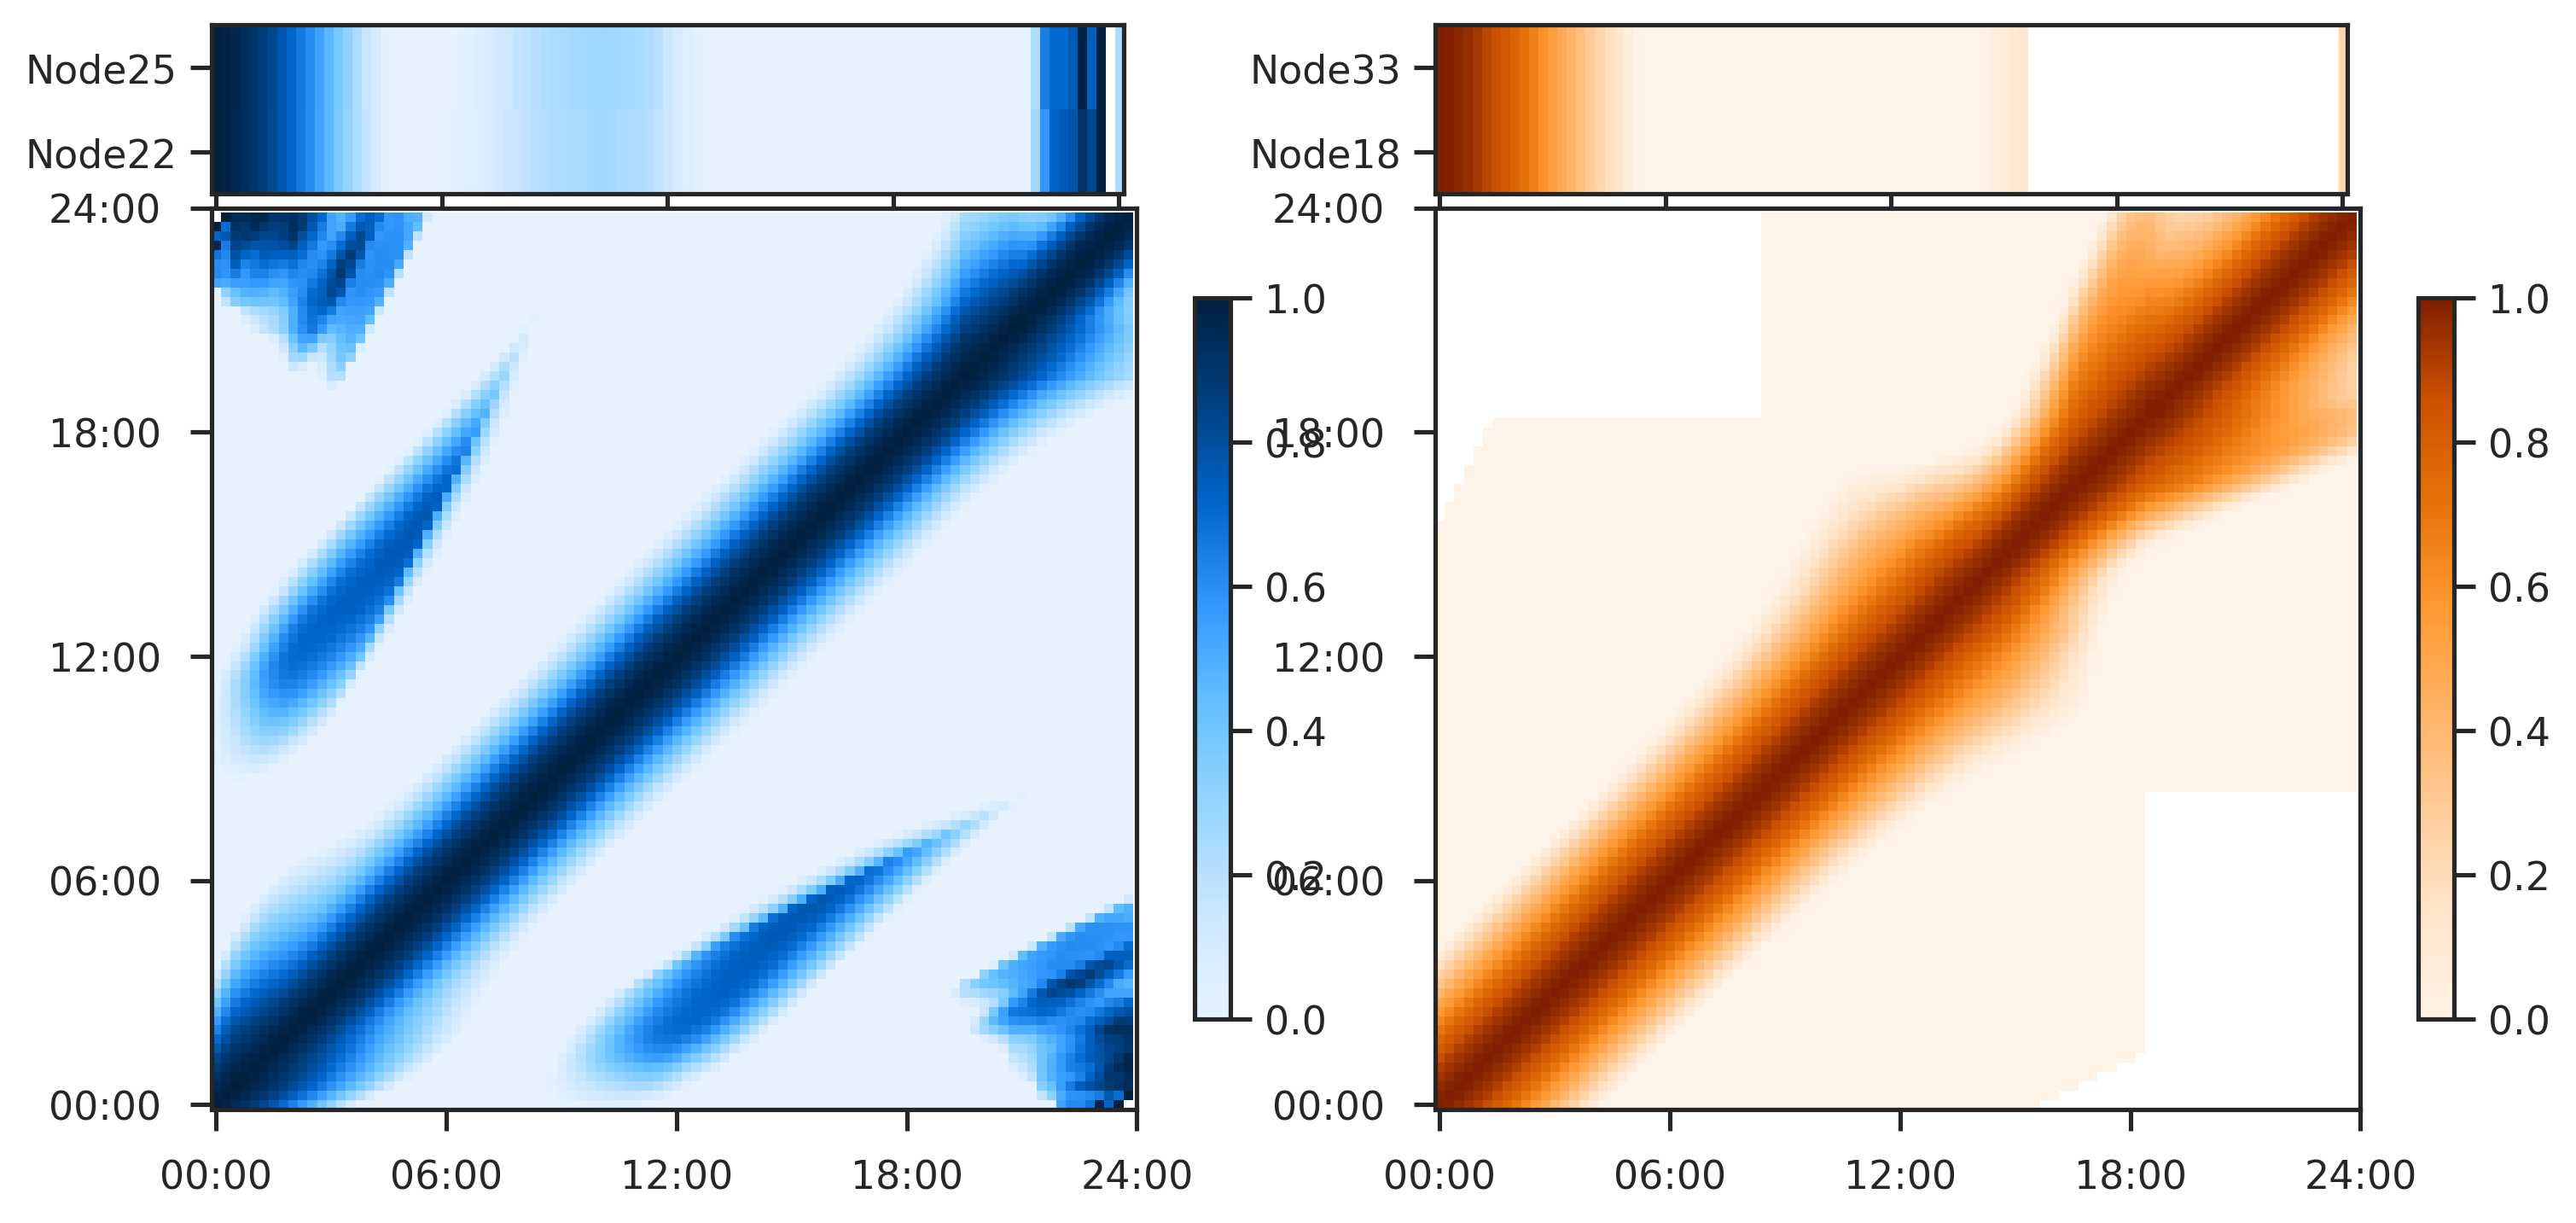

In [1]:
!pip install scienceplots
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd
import scienceplots
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family']='Times New Roman'
plt.rcParams['axes.unicode_minus']= False
sns.set(style='ticks')
plt.style.use(sorted(plt.style.available)[31])


scenario = pd.read_csv(r"/kaggle/input/datasets/belovedorange/research-methodology-project/1-Day Scenarios/1-Day Scenarios/scenario_001.csv")
node22_wind = np.array(scenario.iloc[:,2])
node25_wind = np.array(scenario.iloc[:,3])
node18_PV = np.array(scenario.iloc[:,4])
node33_PV = np.array(scenario.iloc[:,5])

def calculate_autocorr_matrix(data1, data2, max_lag=96):
    n = len(data1)
    autocorr_matrix = np.zeros((2, max_lag+1))

    for lag in range(max_lag+1):
        if lag == 0:
            autocorr_matrix[0, lag] = 1.0
        elif lag < n:
            autocorr_matrix[0, lag] = np.corrcoef(data1[:-lag], data1[lag:])[0, 1]
        else:
            autocorr_matrix[0, lag] = 0

    for lag in range(max_lag+1):
        if lag == 0:
            autocorr_matrix[1, lag] = 1.0
        elif lag < n:
            autocorr_matrix[1, lag] = np.corrcoef(data2[:-lag], data2[lag:])[0, 1]
        else:
            autocorr_matrix[1, lag] = 0
    
    return autocorr_matrix

def calculate_spatial_correlation(data1, data2):
    n = len(data1)
    corr_matrix = np.zeros((n, n))
    
    for i in range(n):
        new_series = np.zeros(n)
        new_series[0] = data1[i]
        for j in range(1, n):
            new_series[j] = data2[(i + j) % n]
        autocorr = np.zeros(n)
        for lag in range(n):
            if lag == 0:
                autocorr[lag] = 1.0
            else:
                if lag < n:
                    autocorr[lag] = np.corrcoef(new_series[:-lag], new_series[lag:])[0, 1]
                else:
                    autocorr[lag] = 0

        for y in range(n):
            matrix_y = (i + y) % n
            corr_matrix[matrix_y, i] = autocorr[y]

    for i in range(n):
        for j in range(i+1, n):
            corr_matrix[i, j] = corr_matrix[j, i]
    
    return corr_matrix

wind_autocorr = calculate_autocorr_matrix(node22_wind, node25_wind, max_lag=96)
pv_autocorr = calculate_autocorr_matrix(node18_PV, node33_PV, max_lag=96)
wind_spatial_corr = calculate_spatial_correlation(node22_wind, node25_wind)
pv_spatial_corr = calculate_spatial_correlation(node18_PV, node33_PV)

blues_colors = ['#e6f3ff', '#cce7ff', '#99d6ff', '#66c2ff', '#3399ff', '#0066cc', '#004080', '#002040']
wind_cmap = LinearSegmentedColormap.from_list('wind_blues', blues_colors)

oranges_colors = ['#fff2e6', '#ffe6cc', '#ffcc99', '#ffb366', '#ff9933', '#e6730a', '#cc5200', '#802000']
pv_cmap = LinearSegmentedColormap.from_list('pv_oranges', oranges_colors)


fig = plt.figure(figsize=(12, 5.5))
grid = plt.GridSpec(18, 20, wspace=1.2, hspace=0.3)

ax1 = fig.add_subplot(grid[:3, :8])
ax11 = fig.add_subplot(grid[3:, :10])
ax2 = fig.add_subplot(grid[:3, 10:18])
ax22 = fig.add_subplot(grid[3:, 10:])

time_labels = ['00:00', '06:00', '12:00', '18:00', '24:00']
time_positions = [0, 24, 48, 72, 96]

vmin_wind, vmax_wind = -0.3, 1
im1 = ax1.imshow(wind_autocorr, aspect='auto', origin='lower', 
                 cmap=wind_cmap, vmin=vmin_wind, vmax=vmax_wind)
ax1.set_ylabel('')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Node22', 'Node25'])
ax1.set_xticks(np.linspace(0, wind_autocorr.shape[1]-1, 5))
ax1.set_xticklabels([])


im11 = ax11.imshow(wind_spatial_corr, aspect='auto', origin='lower',
                   cmap=wind_cmap, vmin=0, vmax=1)
#ax11.set_xlabel('Time')
ax11.set_ylabel('')
ax11.set_xticks(time_positions)
ax11.set_xticklabels(time_labels)
ax11.set_yticks(time_positions)
ax11.set_yticklabels(time_labels)
ax11.tick_params(axis='x', pad=8)
ax11.tick_params(axis='y', pad=8)


im2 = ax2.imshow(pv_autocorr, aspect='auto', origin='lower',
                 cmap=pv_cmap, vmin=vmin_wind, vmax=vmax_wind)
ax2.set_ylabel('')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Node18', 'Node33'])
ax2.set_xticks(np.linspace(0, pv_autocorr.shape[1]-1, 5))
ax2.set_xticklabels([])


im22 = ax22.imshow(pv_spatial_corr, aspect='auto', origin='lower',
                   cmap=pv_cmap, vmin=0, vmax=1)
#ax22.set_xlabel('Time')
pv_time_labels = ['08:15', '10:45', '13:15', '15:45', '18:15']

ax22.set_ylabel('')
ax22.set_xticks(time_positions)
ax22.set_xticklabels(time_labels)
ax22.set_yticks(time_positions)
ax22.set_yticklabels(time_labels)
ax22.tick_params(axis='x', pad=8)
ax22.tick_params(axis='y', pad=8)

cbar11 = plt.colorbar(im11, ax=ax11, shrink=0.8)
#cbar11.set_label('Correlation', rotation=270, labelpad=15)

cbar22 = plt.colorbar(im22, ax=ax22, shrink=0.8)
#cbar22.set_label('Correlation', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()